# Cell 1 — Import packages and load the raw ESS data

In this notebook, we prepare the initial preprocessed data used for the CCA/network analysis in the paper.

The goal is not to reproduce the full CCA analysis yet. The goal is only to create the clean respondent-by-belief-variable dataset that can be shared with collaborators and used in the next stage of analysis.

The raw file is the European Social Survey Round 8 integrated file:

`ESS8e02_3.csv`

The paper uses ESS Round 8 and analyses belief systems across 23 countries. The raw ESS file contains 44,387 respondents. After preprocessing the belief variables and allowing at most two missing belief variables, the paper reports an initial CCA sample size of 37,118 respondents.

In this cell, we:

- import the required Python packages;
- set the input/output data folder;
- load the raw ESS file;
- check the raw number of rows, columns, and countries.

This first check is important because we need to confirm that the correct raw dataset has been loaded before doing any recoding.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

DATA_DIR = Path("./data")
DATA_DIR.mkdir(parents=True, exist_ok=True)

RAW_DATA_PATH = DATA_DIR / "ESS8e02_3.csv"

df = pd.read_csv(RAW_DATA_PATH, low_memory=False)

print("Raw dataframe shape:", df.shape)
print("Number of countries:", df["cntry"].nunique())
print(df["cntry"].value_counts().sort_index())

Raw dataframe shape: (44387, 535)
Number of countries: 23
cntry
AT    2010
BE    1766
CH    1525
CZ    2269
DE    2852
EE    2019
ES    1958
FI    1925
FR    2070
GB    1959
HU    1614
IE    2757
IL    2557
IS     880
IT    2626
LT    2122
NL    1681
NO    1545
PL    1694
PT    1270
RU    2430
SE    1551
SI    1307
Name: count, dtype: int64


# Cell 2 — Define helper functions and country labels

In this cell, we define helper functions that will be used throughout the notebook.

ESS variables often contain special values for responses such as refusal, don't know, no answer, not applicable, or other invalid responses. These values are usually outside the valid response range of the survey item. For example, a variable measured from 1 to 5 may also contain values such as 7, 8, or 9, which represent missing-response categories.

The helper functions do the following:

- `to_numeric_clean()` converts a column to numeric values.
- `valid_range()` keeps only values inside the valid response range and converts all other values to missing values (`NaN`).
- `scale_keep()` rescales a valid variable to the interval 0–1 while keeping its original direction.
- `scale_reverse()` reverse-codes a valid variable and rescales it to the interval 0–1.

Reverse coding is necessary because the paper codes all belief variables so that higher values mean more right-wing, conservative, or anti-progressive responses. Some original ESS variables are already in this direction, but others are in the opposite direction.

For example, if agreement with an item means a more progressive response, but the paper wants higher values to mean a more conservative response, then the item must be reverse coded.

We also define country labels so that the final dataset contains both the ESS country code and the full country name.

In [2]:
def to_numeric_clean(s):
    """
    Convert a column to numeric.
    Non-numeric values become NaN.
    """
    return pd.to_numeric(s, errors="coerce")


def valid_range(s, minv, maxv):
    """
    Keep only values between minv and maxv.
    Everything outside that range becomes NaN.
    """
    x = to_numeric_clean(s)
    return x.where(x.between(minv, maxv))


def scale_keep(s, minv, maxv):
    """
    Rescale to 0-1 while keeping the original direction.
    """
    x = valid_range(s, minv, maxv)
    return (x - minv) / (maxv - minv)


def scale_reverse(s, minv, maxv):
    """
    Reverse-code and rescale to 0-1.
    """
    x = valid_range(s, minv, maxv)
    return (maxv - x) / (maxv - minv)


country_labels = {
    "AT": "Austria",
    "BE": "Belgium",
    "CH": "Switzerland",
    "CZ": "Czechia",
    "DE": "Germany",
    "EE": "Estonia",
    "ES": "Spain",
    "FI": "Finland",
    "FR": "France",
    "GB": "United Kingdom",
    "HU": "Hungary",
    "IE": "Ireland",
    "IL": "Israel",
    "IS": "Iceland",
    "IT": "Italy",
    "LT": "Lithuania",
    "NL": "Netherlands",
    "NO": "Norway",
    "PL": "Poland",
    "PT": "Portugal",
    "RU": "Russian Federation",
    "SE": "Sweden",
    "SI": "Slovenia",
}

# Cell 3 — Create respondent metadata, demographic variables, and ESS weights

In this cell, we create the respondent-level metadata, demographic variables, and ESS survey-weight variables that will be included in the final preprocessed dataset.

The demographic variables are not used to construct the 20 belief variables, but they are useful for later analyses and for collaborators who may want to connect belief systems to demographic characteristics.

The ESS weight variables are also not used as belief variables. They should not be included as nodes in the future CCA or belief-network inference. They are retained only so that later descriptive statistics, country comparisons, or population-representative summaries can be computed correctly when needed.

We include the following identifier variables:

* `ess_row_id`: explicit row number from the original ESS file, starting from 1.
* `idno`: respondent identification number from the ESS file.
* `cntry`: ESS country code.
* `country_name`: full country name.
* `ess_unique_id`: combined country/respondent identifier.

We also include the following demographic variables.

## `agea` — Age

This is the respondent's age in years.

Examples:

* `18` = 18 years old
* `35` = 35 years old
* `70` = 70 years old

The ESS codebook uses special values for missing responses. These are converted to `NaN`.

## `gndr` — Gender

ESS coding:

* `1` = male
* `2` = female

Invalid or missing-response values are converted to `NaN`.

## `eisced` — Original education scale

This is the original ESS education variable, called `eisced`.

The valid values are:

* `1` = ES-ISCED I, less than lower secondary
* `2` = ES-ISCED II, lower secondary
* `3` = ES-ISCED IIIb, lower-tier upper secondary
* `4` = ES-ISCED IIIa, upper-tier upper secondary
* `5` = ES-ISCED IV, advanced vocational, sub-degree
* `6` = ES-ISCED V1, lower tertiary education, BA level
* `7` = ES-ISCED V2, higher tertiary education, MA level or higher

Other values such as `0`, `55`, `77`, `88`, and `99` are treated as missing for our purposes.

## `education_3cat` — Collapsed education variable

The paper collapses the original seven education categories into three categories:

* `1` = less educated, original `eisced` categories 1–2
* `2` = middle educated, original `eisced` categories 3–5
* `3` = higher educated, original `eisced` categories 6–7

This is the education variable that matches the demographic summary in the supplement.

## `hinctnta` — Household income decile

This is household total net income in deciles.

The valid values are:

* `1` = 1st decile, lowest income group
* `2` = 2nd decile
* `3` = 3rd decile
* `4` = 4th decile
* `5` = 5th decile
* `6` = 6th decile
* `7` = 7th decile
* `8` = 8th decile
* `9` = 9th decile
* `10` = 10th decile, highest income group

Thus, higher values mean higher household income.

## `rlgblg` — Religious belonging

ESS coding:

* `1` = yes, belongs to a particular religion or denomination
* `2` = no, does not belong to a particular religion or denomination

This is a binary categorical variable, not a continuous scale.

## `urbanization`

The raw ESS variable is `domicil`, where:

* `1` = big city
* `2` = suburbs or outskirts of big city
* `3` = town or small city
* `4` = country village
* `5` = farm or home in countryside

However, the supplement describes urbanization so that higher values mean more urbanized. Therefore, we reverse the raw `domicil` coding and create `urbanization`:

* `1` = farm or home in countryside
* `2` = country village
* `3` = town or small city
* `4` = suburbs or outskirts of big city
* `5` = big city

This matches the interpretation that higher values mean more urbanized.

## `blgetmg` — Ethnic minority status

ESS coding:

* `1` = yes, respondent belongs to a minority ethnic group in the country
* `2` = no, respondent does not belong to a minority ethnic group in the country

## `vote_simple` — Simple voting participation variable

ESS coding:

* `1` = yes, voted in the last national election
* `2` = no, did not vote in the last national election
* `3` = not eligible to vote

Important: this is not the same as the paper's final `Vote behavior` variable with categories 1–7. The paper's voting-behavior variable was constructed later using party-vote information and The PopuList classification. Here, we only preserve the simple ESS voting-participation variable for reference.

## ESS weight variables

We preserve the official ESS weight variables:

* `dweight`: design weight. This adjusts for unequal probabilities of selection.
* `pspwght`: post-stratification weight including design weight. This adjusts for design, nonresponse, and sampling differences so that the country sample better reflects the population aged 15 or older.
* `pweight`: population size weight. This accounts for the fact that ESS countries have similar sample sizes but very different population sizes.
* `anweight`: analysis weight. In the ESS data, this corresponds to the combined analysis weight and is approximately `pspwght * pweight`.
* `unweighted_weight`: constant value equal to `1.0` for every respondent. This is not an ESS variable. It is added only as a convenient indicator for unweighted analyses.

These weight variables are included in the final dataset for later descriptive or regression analyses. They are not part of the 20 belief variables and should not be included in the CCA/network inference matrix.

This cell does not perform any belief-variable construction yet. It only prepares respondent metadata, demographic information, and weights.


In [3]:
metadata = pd.DataFrame(index=df.index)

metadata["ess_row_id"] = np.arange(1, len(df) + 1)
metadata["idno"] = df["idno"]

metadata["cntry"] = df["cntry"]
metadata["country_name"] = metadata["cntry"].map(country_labels)

metadata["ess_unique_id"] = (
    metadata["cntry"].astype(str) + "_" + metadata["idno"].astype(str)
)

metadata["agea"] = valid_range(df["agea"], 0, 120)

metadata["gndr"] = valid_range(df["gndr"], 1, 2)

metadata["eisced"] = valid_range(df["eisced"], 1, 7)

metadata["education_3cat"] = np.select(
    [
        metadata["eisced"].isin([1, 2]),
        metadata["eisced"].isin([3, 4, 5]),
        metadata["eisced"].isin([6, 7]),
    ],
    [1, 2, 3],
    default=np.nan,
)

metadata["hinctnta"] = valid_range(df["hinctnta"], 1, 10)

metadata["rlgblg"] = valid_range(df["rlgblg"], 1, 2)

# Raw ESS domicil:
# 1 = big city, 5 = farm/countryside.
# We reverse it so that higher values mean more urbanized.
domicil_raw = valid_range(df["domicil"], 1, 5)
metadata["urbanization"] = 6 - domicil_raw

metadata["blgetmg"] = valid_range(df["blgetmg"], 1, 2)

# Simple ESS voting participation variable:
# 1 = voted, 2 = did not vote, 3 = not eligible.
# This is NOT the same as the paper's later 1-7 vote-behavior variable.
metadata["vote_simple"] = valid_range(df["vote"], 1, 3)

# ---------------------------------------------------------------------
# ESS survey weights
# ---------------------------------------------------------------------
# These are preserved for future descriptive statistics, country
# comparisons, and population-representative analyses.
#
# They are NOT belief variables and should NOT be used as nodes in
# the future belief-network / CCA inference.
#
# Official ESS weight columns:
# dweight  = design weight
# pspwght  = post-stratification weight including design weight
# pweight  = population size weight
# anweight = analysis weight, approximately pspwght * pweight
#
# unweighted_weight is not an ESS variable. It is added as a constant
# equal to 1.0 for analyses where every respondent is treated equally.

## uncomment to use weight columns
#weight_columns = ["dweight", "pspwght", "pweight", "anweight"]

#for w in weight_columns:
    #metadata[w] = pd.to_numeric(df[w], errors="coerce")

#metadata["unweighted_weight"] = 1.0

metadata.head()

,ess_row_id,idno,cntry,country_name,ess_unique_id,agea,gndr,eisced,education_3cat,hinctnta,rlgblg,urbanization,blgetmg,vote_simple
0,1,1,AT,Austria,AT_1,34.0,2.0,7.0,3.0,NaN,2.0,5.0,2.0,3.0
1,2,2,AT,Austria,AT_2,52.0,1.0,4.0,2.0,5.0,2.0,5.0,2.0,3.0
2,3,4,AT,Austria,AT_4,68.0,2.0,3.0,2.0,2.0,1.0,2.0,2.0,1.0
3,4,6,AT,Austria,AT_6,54.0,1.0,3.0,2.0,4.0,NaN,5.0,2.0,NaN
4,5,10,AT,Austria,AT_10,20.0,2.0,3.0,2.0,2.0,1.0,3.0,1.0,2.0


# Cell 4 — Define the 20 belief variables and recode the underlying ESS items internally

In this cell, we define and construct the 20 belief variables used in the paper.

The paper uses 20 political belief variables. Some are based on one ESS item, while others are constructed as the average of multiple ESS items.

The paper codes all belief variables so that higher values mean more right-wing or conservative responses.

Important: we do create recoded ESS item columns internally in this cell, but we do not save them as a separate CSV file. They are only temporary intermediate variables needed to construct the final 20 belief variables.

The final network/CCA input is the respondent-by-belief-variable matrix, not the item-level recoded dataframe.

The constructed belief variables are:

1. `left_right_identification`
2. `gender_inequality`
3. `anti_lgbt`
4. `euroscepticism`
5. `anti_immigration`
6. `anti_egalitarianism`
7. `benefits_harm_economy`
8. `benefits_harm_society`
9. `welfare_chauvinism`
10. `anti_economic_interventionism`
11. `anti_social_benefits_low_income`
12. `anti_social_benefits_parents`
13. `educational_spending`
14. `anti_basic_income`
15. `anti_climate_change_taxes`
16. `anti_climate_change_renewables`
17. `anti_climate_ban_appliances`
18. `climate_skepticism`
19. `authoritarianism`
20. `anti_libertarianism`

Each constructed belief variable is on a 0–1 scale.

For multi-item variables, we use strict construction with `skipna=False`. This means that if any underlying ESS item is missing, the constructed belief variable is also missing for that respondent.

This strict construction reproduces the paper's reported descriptive statistics for the 20 belief variables.

In [4]:
belief_map = {
    "left_right_identification": ["lrscale"],
    "gender_inequality": ["mnrgtjb"],
    "anti_lgbt": ["freehms", "hmsfmlsh", "hmsacld"],
    "euroscepticism": ["euftf"],
    "anti_immigration": ["imsmetn", "imdfetn", "impcntr"],
    "anti_egalitarianism": ["gincdif", "dfincac", "smdfslv"],

    # These item groupings follow the main paper's Table 1 meaning
    # and reproduce Supplementary Table A2.
    "benefits_harm_economy": ["sbstrec", "sbbsntx"],
    "benefits_harm_society": ["sbprvpv", "sbeqsoc"],

    "welfare_chauvinism": ["imsclbn"],
    "anti_economic_interventionism": ["gvslvol", "gvslvue", "gvcldcr"],
    "anti_social_benefits_low_income": ["bnlwinc"],
    "anti_social_benefits_parents": ["wrkprbf"],
    "educational_spending": ["eduunmp"],
    "anti_basic_income": ["basinc"],
    "anti_climate_change_taxes": ["inctxff"],
    "anti_climate_change_renewables": ["sbsrnen"],
    "anti_climate_ban_appliances": ["banhhap"],
    "climate_skepticism": ["ccnthum"],
    "authoritarianism": ["impsafe", "ipfrule", "ipbhprp", "ipstrgv", "imptrad"],
    "anti_libertarianism": ["impdiff", "ipadvnt", "ipcrtiv", "impfree", "ipudrst"],
}

belief_columns = list(belief_map.keys())
all_belief_items = sorted({item for items in belief_map.values() for item in items})

# Temporary dataframe used only inside the notebook.
# We do not export this file.
tmp_items = pd.DataFrame(index=df.index)

# Left-right identification
tmp_items["lrscale"] = scale_keep(df["lrscale"], 0, 10)

# Gender inequality
tmp_items["mnrgtjb"] = scale_reverse(df["mnrgtjb"], 1, 5)

# Anti-LGBT
tmp_items["freehms"] = scale_keep(df["freehms"], 1, 5)
tmp_items["hmsfmlsh"] = scale_reverse(df["hmsfmlsh"], 1, 5)
tmp_items["hmsacld"] = scale_keep(df["hmsacld"], 1, 5)

# Euroscepticism
tmp_items["euftf"] = scale_reverse(df["euftf"], 0, 10)

# Anti-immigration
for v in ["imsmetn", "imdfetn", "impcntr"]:
    tmp_items[v] = scale_keep(df[v], 1, 4)

# Anti-egalitarianism
tmp_items["gincdif"] = scale_keep(df["gincdif"], 1, 5)
tmp_items["dfincac"] = scale_reverse(df["dfincac"], 1, 5)
tmp_items["smdfslv"] = scale_keep(df["smdfslv"], 1, 5)

# Benefits harm economy
tmp_items["sbstrec"] = scale_reverse(df["sbstrec"], 1, 5)
tmp_items["sbbsntx"] = scale_reverse(df["sbbsntx"], 1, 5)

# Benefits harm society
tmp_items["sbprvpv"] = scale_keep(df["sbprvpv"], 1, 5)
tmp_items["sbeqsoc"] = scale_keep(df["sbeqsoc"], 1, 5)

# Welfare chauvinism
tmp_items["imsclbn"] = scale_keep(df["imsclbn"], 1, 5)

# Anti-economic interventionism
for v in ["gvslvol", "gvslvue", "gvcldcr"]:
    tmp_items[v] = scale_reverse(df[v], 0, 10)

# Anti-social benefits
tmp_items["bnlwinc"] = scale_reverse(df["bnlwinc"], 1, 4)
tmp_items["wrkprbf"] = scale_reverse(df["wrkprbf"], 1, 4)

# Educational spending
tmp_items["eduunmp"] = scale_keep(df["eduunmp"], 1, 4)

# Anti-basic income
tmp_items["basinc"] = scale_reverse(df["basinc"], 1, 4)

# Climate policy items
tmp_items["inctxff"] = scale_keep(df["inctxff"], 1, 5)
tmp_items["sbsrnen"] = scale_keep(df["sbsrnen"], 1, 5)
tmp_items["banhhap"] = scale_keep(df["banhhap"], 1, 5)

# Climate skepticism
# Keep only valid 1-5 values. Treat 55 and special codes as missing.
ccnthum = to_numeric_clean(df["ccnthum"])
ccnthum = ccnthum.where(ccnthum.isin([1, 2, 3, 4, 5]))
tmp_items["ccnthum"] = (5 - ccnthum) / 4

# Authoritarianism
for v in ["impsafe", "ipfrule", "ipbhprp", "ipstrgv", "imptrad"]:
    tmp_items[v] = scale_reverse(df[v], 1, 6)

# Anti-libertarianism
for v in ["impdiff", "ipadvnt", "ipcrtiv", "impfree", "ipudrst"]:
    tmp_items[v] = scale_keep(df[v], 1, 6)

# Sanity check: all temporary recoded items should be between 0 and 1.
assert tmp_items[all_belief_items].min(skipna=True).min() >= 0
assert tmp_items[all_belief_items].max(skipna=True).max() <= 1

# Construct the final belief-variable dataframe.
beliefs = metadata.copy()

for belief_name, item_list in belief_map.items():
    beliefs[belief_name] = tmp_items[item_list].mean(axis=1, skipna=False)

beliefs["n_belief_missing"] = beliefs[belief_columns].isna().sum(axis=1)
beliefs["n_belief_available"] = len(belief_columns) - beliefs["n_belief_missing"]

print("Constructed belief dataframe shape:", beliefs.shape)
print("Number of belief variables:", len(belief_columns))
beliefs.head()

Constructed belief dataframe shape: (44387, 36)
Number of belief variables: 20


,ess_row_id,idno,cntry,country_name,ess_unique_id,agea,gndr,eisced,education_3cat,hinctnta,...,educational_spending,anti_basic_income,anti_climate_change_taxes,anti_climate_change_renewables,anti_climate_ban_appliances,climate_skepticism,authoritarianism,anti_libertarianism,n_belief_missing,n_belief_available
0,1,1,AT,Austria,AT_1,34.0,2.0,7.0,3.0,NaN,...,NaN,0.000000,0.00,0.00,0.25,0.25,0.20,0.28,1,19
1,2,2,AT,Austria,AT_2,52.0,1.0,4.0,2.0,5.0,...,0.666667,0.333333,0.00,0.25,0.25,0.25,0.24,0.44,0,20
2,3,4,AT,Austria,AT_4,68.0,2.0,3.0,2.0,2.0,...,0.333333,1.000000,0.75,0.25,0.25,0.25,0.72,0.56,0,20
3,4,6,AT,Austria,AT_6,54.0,1.0,3.0,2.0,4.0,...,0.666667,NaN,0.50,0.50,0.50,0.50,0.68,0.28,2,18
4,5,10,AT,Austria,AT_10,20.0,2.0,3.0,2.0,2.0,...,0.333333,0.333333,0.50,0.00,0.75,0.25,0.48,0.40,0,20


# Cell 5 — Create the initial CCA-ready dataset

In this cell, we apply the paper's initial sample rule.

The paper's modified CCA procedure allows respondents to have at most two missing belief variables. Therefore, respondents do not need to have complete data for all 20 belief variables.

The belief-variable rule is:

- keep respondents with `n_belief_missing <= 2`.

This means we keep respondents who have at least 18 out of the 20 belief variables available.

We also exclude respondents who are known to be younger than 18. However, we keep respondents whose age is missing because age is a demographic variable, not one of the 20 belief variables used to construct the CCA input.

Therefore, the age rule is:

- keep respondents with `agea >= 18`;
- also keep respondents where `agea` is missing;
- exclude respondents where `agea < 18`.

The expected result is:

- raw ESS sample size = 44,387;
- initial CCA sample size = 37,118;
- number of countries = 23;
- number of belief variables = 20.

This final dataframe, `cca_initial`, is the main preprocessed dataset needed for the future CCA/network inference step.

Important: the final dataframe also contains demographic variables and ESS weight variables. These variables are preserved for documentation and later descriptive or regression analyses. They should not be included as belief variables in the CCA/network matrix.

For CCA/network inference, we should select only the 20 belief columns stored in `belief_columns`.


In [5]:
adult_or_missing_age = beliefs["agea"].ge(18) | beliefs["agea"].isna()

cca_initial = beliefs.loc[
    adult_or_missing_age & (beliefs["n_belief_missing"] <= 2)
].copy()

print("Raw ESS N:", len(df))
print("Initial CCA N:", len(cca_initial))
print("Countries:", cca_initial["cntry"].nunique())
print("Belief variables:", len(belief_columns))

assert len(df) == 44387
assert len(cca_initial) == 37118
assert cca_initial["cntry"].nunique() == 23
assert len(belief_columns) == 20

cca_initial["cntry"].value_counts().sort_index()

Raw ESS N: 44387
Initial CCA N: 37118
Countries: 23
Belief variables: 20


cntry
AT    1766
BE    1672
CH    1318
CZ    1920
DE    2619
EE    1836
ES    1495
FI    1795
FR    1905
GB    1791
HU    1194
IE    2360
IL    1849
IS     789
IT    1937
LT    1478
NL    1541
NO    1431
PL    1297
PT    1134
RU    1515
SE    1372
SI    1104
Name: count, dtype: int64

# Cell 6 — Validate the belief variables against the paper

In this cell, we validate our constructed belief variables against Supplementary Table A2 of the paper.

For each of the 20 belief variables, we calculate:

- reproduced `N`;
- reproduced mean;
- reproduced standard deviation.

We then compare these values with the paper's reported values.

This validation is important because it checks whether the preprocessing decisions are consistent with the paper.

The expected result is that:

- the reproduced non-missing `N` values match the paper exactly;
- the reproduced means and standard deviations match the paper when rounded to two decimal places.

This validation table is saved later as:

`ess8_belief_validation_against_paper.csv`

In [6]:
reproduced_stats = (
    cca_initial[belief_columns]
    .agg(["count", "mean", "std"])
    .T
    .reset_index()
    .rename(columns={
        "index": "belief_variable",
        "count": "N_reproduced",
        "mean": "mean_reproduced",
        "std": "sd_reproduced",
    })
)

reproduced_stats["N_reproduced"] = reproduced_stats["N_reproduced"].astype(int)

paper_stats = pd.DataFrame([
    ["left_right_identification", 34248, 0.51, 0.22],
    ["gender_inequality", 37038, 0.23, 0.27],
    ["anti_lgbt", 36098, 0.34, 0.27],
    ["euroscepticism", 35848, 0.51, 0.27],
    ["anti_immigration", 36459, 0.45, 0.27],
    ["anti_egalitarianism", 36772, 0.38, 0.19],
    ["benefits_harm_economy", 35956, 0.49, 0.23],
    ["benefits_harm_society", 36801, 0.41, 0.22],
    ["welfare_chauvinism", 36441, 0.54, 0.26],
    ["anti_economic_interventionism", 36927, 0.24, 0.16],
    ["anti_social_benefits_low_income", 36399, 0.55, 0.27],
    ["anti_social_benefits_parents", 36026, 0.47, 0.24],
    ["educational_spending", 36227, 0.57, 0.25],
    ["anti_basic_income", 35785, 0.50, 0.27],
    ["anti_climate_change_taxes", 36832, 0.55, 0.31],
    ["anti_climate_change_renewables", 37028, 0.26, 0.26],
    ["anti_climate_ban_appliances", 36962, 0.36, 0.29],
    ["climate_skepticism", 36035, 0.39, 0.20],
    ["authoritarianism", 36631, 0.66, 0.17],
    ["anti_libertarianism", 36769, 0.35, 0.16],
], columns=["belief_variable", "N_paper", "mean_paper", "sd_paper"])

validation = paper_stats.merge(reproduced_stats, on="belief_variable", how="left")

validation["mean_reproduced_round2"] = validation["mean_reproduced"].round(2)
validation["sd_reproduced_round2"] = validation["sd_reproduced"].round(2)

validation["N_matches"] = validation["N_reproduced"] == validation["N_paper"]
validation["mean_matches_round2"] = validation["mean_reproduced_round2"] == validation["mean_paper"]
validation["sd_matches_round2"] = validation["sd_reproduced_round2"] == validation["sd_paper"]

assert validation["N_matches"].all()
assert validation["mean_matches_round2"].all()
assert validation["sd_matches_round2"].all()

validation

,belief_variable,N_paper,mean_paper,sd_paper,N_reproduced,mean_reproduced,sd_reproduced,mean_reproduced_round2,sd_reproduced_round2,N_matches,mean_matches_round2,sd_matches_round2
0,left_right_identification,34248,0.51,0.22,34248,0.512920,0.223370,0.51,0.22,True,True,True
1,gender_inequality,37038,0.23,0.27,37038,0.227955,0.269111,0.23,0.27,True,True,True
2,anti_lgbt,36098,0.34,0.27,36098,0.336637,0.270381,0.34,0.27,True,True,True
3,euroscepticism,35848,0.51,0.27,35848,0.508968,0.266828,0.51,0.27,True,True,True
4,anti_immigration,36459,0.45,0.27,36459,0.451734,0.265234,0.45,0.27,True,True,True
5,anti_egalitarianism,36772,0.38,0.19,36772,0.380239,0.193550,0.38,0.19,True,True,True
6,benefits_harm_economy,35956,0.49,0.23,35956,0.490534,0.226702,0.49,0.23,True,True,True
7,benefits_harm_society,36801,0.41,0.22,36801,0.410132,0.218079,0.41,0.22,True,True,True
8,welfare_chauvinism,36441,0.54,0.26,36441,0.543090,0.258760,0.54,0.26,True,True,True
9,anti_economic_interventionism,36927,0.24,0.16,36927,0.244343,0.159874,0.24,0.16,True,True,True


# Cell 7 — Create the README file

In this cell, we create a README text file describing the final preprocessed dataset.

The README is important because collaborators should be able to understand the dataset without reading the entire notebook.

The README explains:

- what raw data were used;
- what files are produced;
- what the final sample size is;
- what demographic variables mean;
- what each number means for demographic variables;
- what the ESS weight variables mean;
- which columns should and should not be used for CCA/network inference;
- what the 20 belief variables mean;
- how missing values were handled;
- why the temporary recoded ESS item dataframe is not exported.

This README is saved as:

`README_ess8_cca_initial_beliefs.txt`

In [7]:
belief_descriptions = {
    "left_right_identification": "Left-right self-placement; higher = more right-wing.",
    "gender_inequality": "Belief that men should have more right to jobs than women when jobs are scarce; higher = more gender-inegalitarian.",
    "anti_lgbt": "Negative attitudes toward gay and lesbian rights; higher = more anti-LGBT.",
    "euroscepticism": "View that European unification has gone too far; higher = more Eurosceptic.",
    "anti_immigration": "Preference to allow fewer immigrants; higher = more anti-immigration.",
    "anti_egalitarianism": "Lower support for income equality and egalitarian society; higher = more anti-egalitarian.",
    "benefits_harm_economy": "Belief that social benefits/services harm the economy or cost businesses too much; higher = stronger belief in economic harm.",
    "benefits_harm_society": "Belief that social benefits/services are socially harmful or less beneficial for poverty/equality; higher = stronger belief in social harm.",
    "welfare_chauvinism": "Preference to delay immigrants' access to social benefits/services; higher = more welfare chauvinist.",
    "anti_economic_interventionism": "Lower support for government responsibility for old age, unemployment, and childcare; higher = more anti-interventionist.",
    "anti_social_benefits_low_income": "Preference to restrict social benefits to the lowest incomes; higher = more anti-universal benefits.",
    "anti_social_benefits_parents": "Opposition to extra benefits for working parents if taxes rise; higher = more opposed.",
    "educational_spending": "Support for spending more on education/training for unemployed at the cost of unemployment benefit; higher = more support for this tradeoff.",
    "anti_basic_income": "Opposition to a basic income scheme; higher = more opposed.",
    "anti_climate_change_taxes": "Opposition to increasing taxes on fossil fuels; higher = more opposed.",
    "anti_climate_change_renewables": "Opposition to subsidizing renewable energy; higher = more opposed.",
    "anti_climate_ban_appliances": "Opposition to banning least energy-efficient household appliances; higher = more opposed.",
    "climate_skepticism": "Belief that climate change is caused less by human activity; higher = more climate-skeptical.",
    "authoritarianism": "Value priorities around security, rules, proper behavior, strong government, and tradition; higher = more authoritarian.",
    "anti_libertarianism": "Lower value placed on creativity, adventure, freedom, and understanding others; higher = more anti-libertarian.",
}

readme_text = f"""
README: ESS8 Initial CCA Belief Dataset
======================================

Purpose
-------
This dataset reproduces the initial preprocessed data used for the CCA/network stage of the paper:
"The nature and structure of European belief systems: exploring the varieties of belief systems across 23 European countries."

The output is intended for data curation and the next stage of analysis. It does not reproduce the full CCA algorithm yet.

Files produced
--------------
1. ess8_cca_initial_beliefs.csv
   Main preprocessed dataset.
   Contains respondent identifiers, country information, demographic variables, ESS weight variables, the 20 constructed belief variables, and missingness counts.
   
2. ess8_belief_validation_against_paper.csv
   Validation table comparing reproduced N, mean, and SD for each belief variable against Supplementary Table A2.

3. README_ess8_cca_initial_beliefs.txt
   This documentation file.


Raw input
---------
Raw ESS file: ESS8e02_3.csv
Raw ESS N: {len(df)}
Raw countries: {df["cntry"].nunique()}

Final preprocessed sample
-------------------------
Final CCA-ready N: {len(cca_initial)}
Countries: {cca_initial["cntry"].nunique()}
Constructed belief variables: {len(belief_columns)}

Sample rule
-----------
Respondents were retained if:
1. They were aged 18 or older, OR age was missing.
2. They had at most two missing belief variables.

This matches the paper's modified CCA preprocessing strategy, which allowed respondents to have a maximum of two missing belief variables.

Missing values
--------------
Invalid ESS codes such as refusal, don't know, no answer, not applicable, and other out-of-range values were converted to NaN.
Missing belief values are not imputed in this preprocessing step.

Identifier variables
--------------------
ess_row_id:
    Explicit row number from the raw ESS file, starting at 1.

idno:
    Respondent ID from the ESS file.

cntry:
    ESS country code.

country_name:
    Full country name.

ess_unique_id:
    Combined country code and respondent ID.

Demographic variables
---------------------
agea:
    Age in years.
    Example: 18 = 18 years old, 35 = 35 years old.
    Missing age is NaN.

gndr:
    1 = male
    2 = female

eisced:
    Original ESS education scale.
    1 = ES-ISCED I, less than lower secondary
    2 = ES-ISCED II, lower secondary
    3 = ES-ISCED IIIb, lower-tier upper secondary
    4 = ES-ISCED IIIa, upper-tier upper secondary
    5 = ES-ISCED IV, advanced vocational, sub-degree
    6 = ES-ISCED V1, lower tertiary education, BA level
    7 = ES-ISCED V2, higher tertiary education, MA level or higher

education_3cat:
    Collapsed education variable used for paper-style demographic analysis.
    1 = less educated, from eisced 1-2
    2 = middle educated, from eisced 3-5
    3 = higher educated, from eisced 6-7

hinctnta:
    Household income decile.
    1 = lowest income decile
    2 = second income decile
    ...
    10 = highest income decile

rlgblg:
    Religious belonging.
    1 = yes
    2 = no

urbanization:
    Reversed from the raw ESS domicil variable so that higher values mean more urbanized.
    1 = farm or home in countryside
    2 = country village
    3 = town or small city
    4 = suburbs or outskirts of big city
    5 = big city

blgetmg:
    Minority ethnic group status.
    1 = yes
    2 = no

vote_simple:
    Simple ESS voting participation variable.
    1 = voted in last national election
    2 = did not vote in last national election
    3 = not eligible to vote

    Important:
    This is not the same as the paper's final 1-7 Vote behavior variable.
    The paper's voting-behavior variable requires party-vote variables and external PopuList classification.

ESS weight variables
--------------------
The final dataset preserves the official ESS weight variables.

dweight:
    Design weight.
    This adjusts for unequal probabilities of selection into the ESS sample.

pspwght:
    Post-stratification weight including design weight.
    This adjusts the sample so that each country sample better reflects the population aged 15 or older with respect to population structure such as gender, age group, education, and region.
    ESS recommends this weight for analyses that aim to make inferences about the general population of a country or for comparisons between countries.

pweight:
    Population size weight.
    This accounts for the fact that ESS countries have similar sample sizes but very different population sizes.
    It is needed when combining countries to estimate results for a larger region or for all ESS countries together.

anweight:
    Analysis weight.
    In the ESS file, this is the combined analysis weight and is approximately pspwght multiplied by pweight.
    It is useful for analyses combining multiple countries.

unweighted_weight:
    Constant value equal to 1.0 for every respondent.
    This is not an original ESS variable.
    It is included only as a convenient marker for unweighted analyses.

Important:
    Weight variables are not belief variables.
    They should not be included as nodes in the CCA/network inference.
    For CCA/network inference, use only the 20 variables listed under "Belief variables".

Belief variables
----------------
All belief variables are scaled from 0 to 1.
Higher values indicate more right-wing, conservative, or anti-progressive responses.

"""

for var in belief_columns:
    readme_text += f"{var}:\n    {belief_descriptions[var]}\n\n"

readme_text += """
Columns to use for future CCA/network inference
-----------------------------------------------
For future CCA or belief-network inference, use only the following 20 belief variables:

left_right_identification
gender_inequality
anti_lgbt
euroscepticism
anti_immigration
anti_egalitarianism
benefits_harm_economy
benefits_harm_society
welfare_chauvinism
anti_economic_interventionism
anti_social_benefits_low_income
anti_social_benefits_parents
educational_spending
anti_basic_income
anti_climate_change_taxes
anti_climate_change_renewables
anti_climate_ban_appliances
climate_skepticism
authoritarianism
anti_libertarianism

Do not include identifier columns, demographic variables, voting variables, ESS weight variables, or missingness-count variables as belief-network nodes.

Missingness-count variables
---------------------------
n_belief_missing:
    Number of missing belief variables among the 20 constructed belief variables.

n_belief_available:
    Number of available belief variables among the 20 constructed belief variables.

Validation
----------
The validation file compares reproduced N, mean, and SD against Supplementary Table A2.
The reproduced N values match exactly, and means/SDs match the paper when rounded to two decimal places.
"""

readme_path = DATA_DIR / "README_ess8_cca_initial_beliefs.txt"

with open(readme_path, "w", encoding="utf-8") as f:
    f.write(readme_text)

print("README saved to:", readme_path)

README saved to: data/README_ess8_cca_initial_beliefs.txt


# Cell 8 — Save only the required output files

In this cell, we save only the required files.

We save:

1. `ess8_cca_initial_beliefs.csv`

   This is the main preprocessed data file needed for future CCA/network inference.

2. `ess8_belief_validation_against_paper.csv`

   This validates the constructed belief variables against the paper.

3. `README_ess8_cca_initial_beliefs.txt`

   This describes the dataset and explains all variables.

We do not save a separate recoded-item file because it is only an intermediate object and is not directly needed for future network inference.

In [8]:
main_data_path = DATA_DIR / "ess8_cca_initial_beliefs.csv"
validation_path = DATA_DIR / "ess8_belief_validation_against_paper.csv"

cca_initial.to_csv(main_data_path, index=False)
validation.to_csv(validation_path, index=False)

print("Saved required files:")
print(main_data_path)
print(validation_path)
print(readme_path)

Saved required files:
data/ess8_cca_initial_beliefs.csv
data/ess8_belief_validation_against_paper.csv
data/README_ess8_cca_initial_beliefs.txt


In [9]:
print("Weight variables included:")
for w in ["dweight", "pspwght", "pweight", "anweight", "unweighted_weight"]:
    print(f"{w}: {w in cca_initial.columns}")

#assert all(
#    w in cca_initial.columns
#    for w in ["dweight", "pspwght", "pweight", "anweight", "unweighted_weight"]
#)

#print("\nWeight summary in final CCA-ready sample:")
#display(
#    cca_initial[
#        ["dweight", "pspwght", "pweight", "anweight", "unweighted_weight"]
#    ].describe()
#)

Weight variables included:
dweight: False
pspwght: False
pweight: False
anweight: False
unweighted_weight: False


In [10]:
#print("Weight variables:", ["dweight", "pspwght", "pweight", "anweight", "unweighted_weight"])

,age_group,N,percent_of_valid_age_sample
0,18-29,5917,15.98
1,30-44,9205,24.85
2,45-59,10034,27.09
3,60-74,8719,23.54
4,75+,3160,8.53
5,NaN,83,0.22


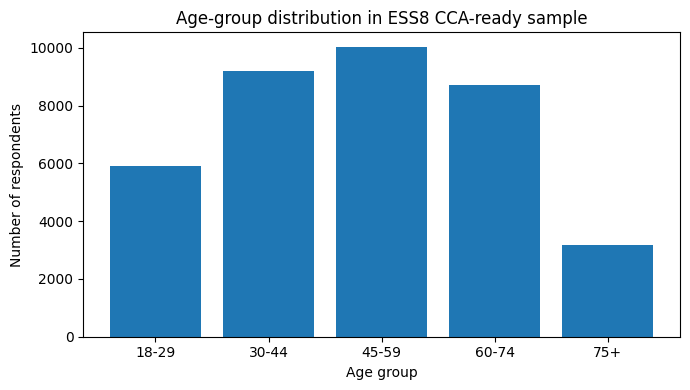

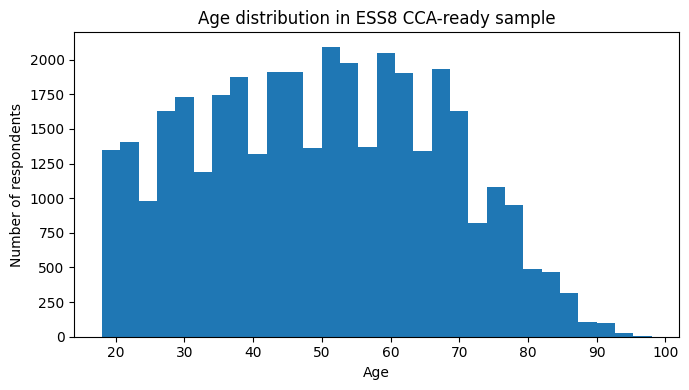

Saved figures:
data/figures/ess8_age_group_distribution.png
data/figures/ess8_age_distribution_histogram.png


In [11]:
import matplotlib.pyplot as plt

# Folder to save figures
FIG_DIR = DATA_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Load the saved final CCA-ready dataset.
cca_file = DATA_DIR / "ess8_cca_initial_beliefs.csv"
age_df = pd.read_csv(cca_file)

# Clean age just to be safe.
age = pd.to_numeric(age_df["agea"], errors="coerce")
age = age.where(age.between(18, 120))

# Create age groups.
age_groups = pd.cut(
    age,
    bins=[18, 30, 45, 60, 75, np.inf],
    labels=["18-29", "30-44", "45-59", "60-74", "75+"],
    right=False
)

age_group_table = (
    age_groups
    .value_counts(dropna=False)
    .sort_index()
    .rename_axis("age_group")
    .reset_index(name="N")
)

age_group_table["percent_of_valid_age_sample"] = (
    100 * age_group_table["N"] / age.notna().sum()
).round(2)

display(age_group_table)

# -----------------------------
# Save age-group bar plot
# -----------------------------

plot_data = age_group_table.dropna(subset=["age_group"])

plt.figure(figsize=(7, 4))
plt.bar(
    plot_data["age_group"].astype(str),
    plot_data["N"]
)
plt.xlabel("Age group")
plt.ylabel("Number of respondents")
plt.title("Age-group distribution in ESS8 CCA-ready sample")
plt.tight_layout()

plt.savefig(FIG_DIR / "ess8_age_group_distribution.png", dpi=600, bbox_inches="tight")

plt.show()

# -----------------------------
# Save continuous age histogram
# -----------------------------

plt.figure(figsize=(7, 4))
plt.hist(age.dropna(), bins=30)
plt.xlabel("Age")
plt.ylabel("Number of respondents")
plt.title("Age distribution in ESS8 CCA-ready sample")
plt.tight_layout()

plt.savefig(FIG_DIR / "ess8_age_distribution_histogram.png", dpi=600, bbox_inches="tight")

plt.show()

print("Saved figures:")
print(FIG_DIR / "ess8_age_group_distribution.png")
print(FIG_DIR / "ess8_age_distribution_histogram.png")
